In [64]:
# going to begin import necessary packages
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
# importing the necessary packages for the model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
# for the first model going to attempt to do a resnet18 model
from torchvision.models import resnet18, ResNet18_Weights
from torch.nn import Module
from PIL import Image
from io import BytesIO
import requests
from torch.utils.data import DataLoader, Dataset, random_split
from torch import Generator
import torch

In [65]:
import os
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-80GB


In [66]:
# read df
df = pd.read_csv('final_df.csv')
df.head(2)

,Unnamed: 0,filename,link,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_data
0,0,1638,http://assets.myntassets.com/v1/images/style/p...,1638,Unisex,Apparel,Bottomwear,Swimwear,Blue,Fall,2010.0,Sports,Nabaiji Swimming Goggles Blue Black,<PIL.Image.Image image mode=RGB size=1800x2400...
1,1,32903,http://assets.myntassets.com/v1/images/style/p...,32903,Women,Apparel,Bottomwear,Shorts,Red,Summer,2012.0,Casual,Allen Solly Women Red Shorts,<PIL.Image.Image image mode=RGB size=1080x1440...


In [67]:
df['subCategory'].value_counts()

,count
subCategory,
Bottomwear,500
Topwear,500
Shoes,500


In [68]:
df['season'].value_counts()

,count
season,
Summer,815
Fall,500
Winter,158
Spring,26


In [69]:
# combine adult and child genders
df.loc[df['gender'].isin(['Girls','Women']),'gender'] = 'Female'
df.loc[df['gender'].isin(['Boys','Men']),'gender'] = 'Male'

In [70]:
# going to create a new label for the CNN; the label will consist of gender, season, and subcategory!
pd.set_option('display.max_rows', None)
df['img_label'] = df['subCategory'] + ' ' + df['season'] + ' ' + df['gender']
df['img_label'].value_counts()

,count
img_label,
Topwear Summer Male,178
Bottomwear Summer Female,150
Bottomwear Summer Male,148
Shoes Summer Male,141
Topwear Summer Female,128
Shoes Fall Male,116
Topwear Fall Male,114
Bottomwear Fall Male,110
Shoes Winter Female,97


In [71]:
# image tens0rizing and stuff
class ImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        # convert labels to numeric
        self.label_map = {label: i for i, label in enumerate(df['img_label'].unique())}
        self.df['label'] = self.df['img_label'].map(self.label_map)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        url = self.df.iloc[idx]['link']
        label = self.df.iloc[idx]['label']


        try:
            response = requests.get(url, timeout=5)
            img = Image.open(BytesIO(response.content)).convert('RGB')
        except:
            return self.__getitem__((idx + 1) % len(self.df))

        if self.transform:
            img = self.transform(img)

        return img, label

In [72]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [73]:
# need to get the number of classes in the in the articletype clothing
num_of_classes = df['img_label'].nunique() + 1
print(num_of_classes)

28


In [74]:
dataset = ImageDataset(df, transform=transform)
print(dataset.df['label'].min())
print(dataset.df['label'].max())
# copying code from assignment 2
SEED = 42
TEST_RATIO = 0.2
size_all = len(dataset)
size_test = int(size_all * TEST_RATIO)
size_train = size_all - size_test

dataset_train, dataset_test = random_split(dataset, [size_train, size_test], generator=Generator().manual_seed(SEED))

0
27


---------

vgg


In [75]:
import torch.nn as nn
import torch.optim as optim

In [76]:
from torchvision.models import vgg16, VGG16_Weights
model_conv = vgg16(weights=VGG16_Weights.DEFAULT)

In [77]:
model_conv.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [78]:
# freeze
for param in model_conv.parameters():
    param.requires_grad = False

#params
num_ftrs = model_conv.classifier[6].in_features
model_conv.classifier[6] = torch.nn.Linear(num_ftrs, num_of_classes)

In [79]:
import torch.optim as optim
from torch.optim import lr_scheduler
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_conv = model_conv.to(device)
criterion = nn.CrossEntropyLoss()

In [80]:
optimizer = optim.SGD(model_conv.parameters(), lr=0.01, momentum=0.9)

In [81]:
# now going to train the model
num_epochs = 50
train_losses, train_acc_list, test_losses, test_acc_list = [], [], [], []
trainloader = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=True, num_workers=1)
testloader = torch.utils.data.DataLoader(dataset_test, batch_size=16, shuffle=False, num_workers=1)

data_iter = iter(trainloader)
images, labels = next(data_iter)



for epoch in range(num_epochs):
    model_conv.train()
    running_loss = 0.0
    correct, total = 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        if labels.ndim > 1:
          labels = labels.argmax(dim=1)
        labels = labels.long()
        optimizer.zero_grad()
        outputs = model_conv(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        # update total and correct
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    # added train acc
    train_acc = correct / total
    train_acc_list.append(train_acc)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")

    # eval phase
    model_conv.eval()
    with torch.no_grad():
      correct = 0
      total_loss = 0
      size = 0
      for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        if labels.ndim > 1:
          labels = labels.argmax(dim=1)
        labels = labels.long()
        outputs = model_conv(inputs)
        # print("outputs shape:", outputs.shape)
        # print("labels shape:", labels.shape)
        # print("labels min/max:", labels.min().item(), labels.max().item())
        # print("labels dtype:", labels.dtype)
        assert labels.dtype == torch.long
        assert labels.min() >= 0
        assert labels.max() < num_of_classes
        loss = criterion(outputs,labels)
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).float().sum().item()
        size += labels.size(0)
      avg_test_loss = total_loss / len(testloader)
      test_losses.append(avg_test_loss)
    accuracy = correct / size
    # added acc append
    test_acc_list.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Test Loss: {avg_test_loss:.4f}, Test Acc: {accuracy:.4f}")
    #print(f"Test Error:\n Accuracy: {(100 * accuracy):>0.1f}%\n")

Epoch 1/50, Train Loss: 4.8467, Train Acc: 0.3700
Epoch 1/50, Test Loss: 5.4054, Test Acc: 0.4300
Epoch 2/50, Train Loss: 6.4607, Train Acc: 0.4142
Epoch 2/50, Test Loss: 6.2563, Test Acc: 0.4133
Epoch 3/50, Train Loss: 6.2635, Train Acc: 0.4667
Epoch 3/50, Test Loss: 6.5590, Test Acc: 0.3933
Epoch 4/50, Train Loss: 6.0348, Train Acc: 0.4983
Epoch 4/50, Test Loss: 5.0672, Test Acc: 0.4833
Epoch 5/50, Train Loss: 7.0207, Train Acc: 0.4758
Epoch 5/50, Test Loss: 5.9584, Test Acc: 0.4567
Epoch 6/50, Train Loss: 6.3666, Train Acc: 0.5083
Epoch 6/50, Test Loss: 8.1078, Test Acc: 0.4833
Epoch 7/50, Train Loss: 6.6141, Train Acc: 0.5258
Epoch 7/50, Test Loss: 6.1482, Test Acc: 0.4867
Epoch 8/50, Train Loss: 6.5405, Train Acc: 0.5342
Epoch 8/50, Test Loss: 7.9965, Test Acc: 0.4767
Epoch 9/50, Train Loss: 7.3559, Train Acc: 0.5317
Epoch 9/50, Test Loss: 7.3816, Test Acc: 0.4367
Epoch 10/50, Train Loss: 6.1389, Train Acc: 0.5658
Epoch 10/50, Test Loss: 7.4881, Test Acc: 0.4533
Epoch 11/50, Train

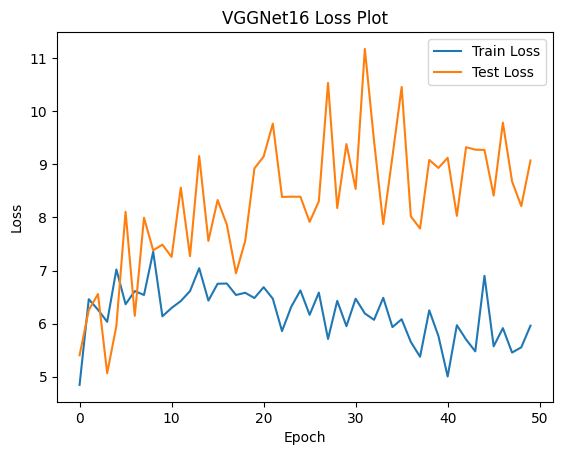

In [82]:
# loss plot
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('VGGNet16 Loss Plot')
plt.savefig('Loss_plot.png')
plt.show()

In [83]:
train_acc_list

[0.37,
 0.4141666666666667,
 0.4666666666666667,
 0.49833333333333335,
 0.47583333333333333,
 0.5083333333333333,
 0.5258333333333334,
 0.5341666666666667,
 0.5316666666666666,
 0.5658333333333333,
 0.5416666666666666,
 0.5583333333333333,
 0.5616666666666666,
 0.5366666666666666,
 0.5775,
 0.5583333333333333,
 0.5625,
 0.5858333333333333,
 0.5633333333333334,
 0.5883333333333334,
 0.5533333333333333,
 0.5758333333333333,
 0.5983333333333334,
 0.5933333333333334,
 0.59,
 0.6066666666666667,
 0.6016666666666667,
 0.6308333333333334,
 0.6016666666666667,
 0.6108333333333333,
 0.6066666666666667,
 0.6,
 0.6291666666666667,
 0.6175,
 0.6375,
 0.6108333333333333,
 0.6433333333333333,
 0.6341666666666667,
 0.6216666666666667,
 0.6358333333333334,
 0.65,
 0.6291666666666667,
 0.635,
 0.635,
 0.6258333333333334,
 0.6483333333333333,
 0.635,
 0.6425,
 0.65,
 0.6466666666666666]

In [85]:
# train and test lost and acc to df
df_loss = pd.DataFrame({'train_loss': train_losses, 'test_loss': test_losses})
df_acc = pd.DataFrame({'train_acc': train_acc_list, 'test_acc': test_acc_list})
# df to csv
df_loss.to_csv('vgg_loss_df.csv', index=False)
df_acc.to_csv('vgg_acc_df.csv', index=False)

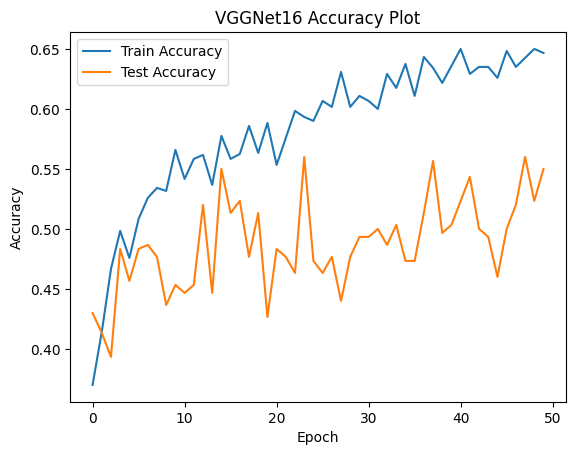

In [84]:
# accuracy plot
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGGNet16 Accuracy Plot')
plt.savefig('Accuracy_plot.png')
plt.legend()
plt.show()


---

In [89]:
# avg test accuracy
avg_test = sum(test_acc_list) / len(test_acc_list)

# avg train acc
avg_train = sum(train_acc_list) / len(train_acc_list)


#avg tes loss
avg_test_loss = sum(test_losses) / len(test_losses)


#avg train loss
avg_train_loss = sum(train_losses) / len(train_losses)


# format outputs for avgs
print(f"Avg test accuracy: {avg_test:.4f}")
print(f"Avg train accuracy: {avg_train:.4f}")
print(f"Avg test loss: {avg_test_loss:.4f}")
print(f"Avg train loss: {avg_train_loss:.4f}")

Avg test accuracy: 0.4873
Avg train accuracy: 0.5824
Avg test loss: 8.2774
Avg train loss: 6.2040


______________

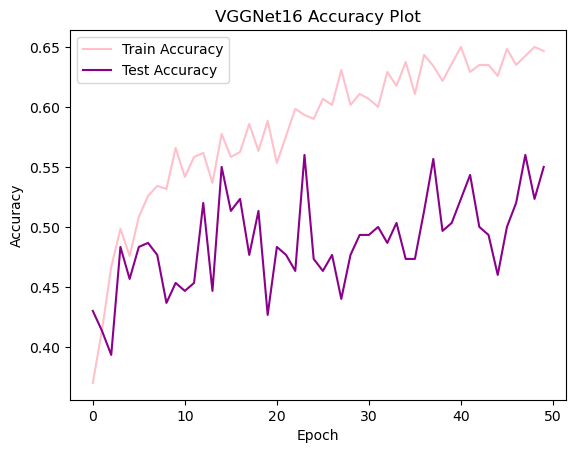

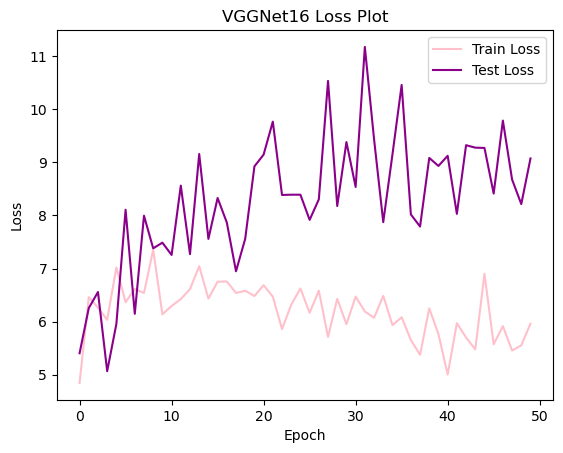

In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load df
df_loss = pd.read_csv('vgg_loss_df.csv')
df_acc = pd.read_csv('vgg_acc_df.csv')

# df to list
train_losses = df_loss['train_loss'].tolist()
test_losses = df_loss['test_loss'].tolist()
train_acc_list = df_acc['train_acc'].tolist()
test_acc_list = df_acc['test_acc'].tolist()



# accuracy plot
plt.plot(train_acc_list, label='Train Accuracy', color='pink')
plt.plot(test_acc_list, label='Test Accuracy', color='#8B008B')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGGNet16 Accuracy Plot')
plt.savefig('Accuracy_plot.png')
plt.legend()
plt.show()

# loss plot
plt.plot(train_losses, label='Train Loss', color='pink')
plt.plot(test_losses, label='Test Loss', color='#8B008B')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('VGGNet16 Loss Plot')
plt.savefig('Loss_plot.png')
plt.show()